Medical insurance cost prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


<Axes: xlabel='age', ylabel='charges'>

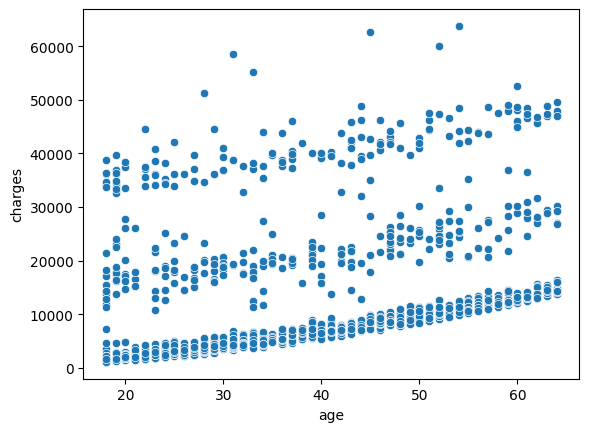

In [ ]:
sns.scatterplot(x='age',y='charges',data=df)

<Axes: xlabel='bmi', ylabel='charges'>

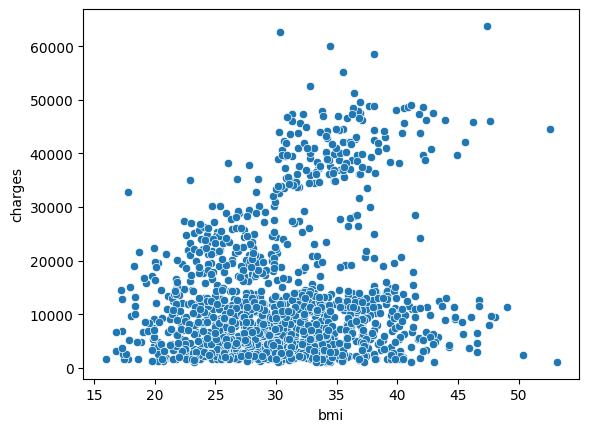

In [ ]:
sns.scatterplot(x='bmi',y='charges',data=df)

In [ ]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

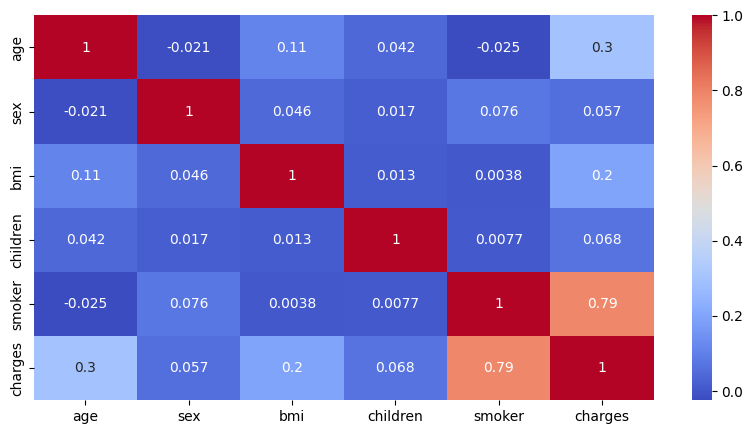

In [ ]:
plt.figure(figsize=(10,5))
correlation_matrix = df.drop(columns=['region']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

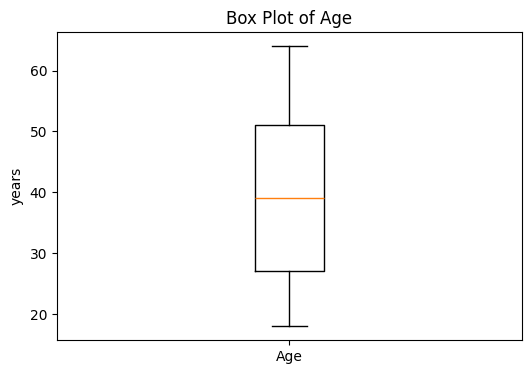

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['age'],tick_labels=['Age'])
plt.title('Box Plot of Age')
plt.ylabel('years')
plt.show()


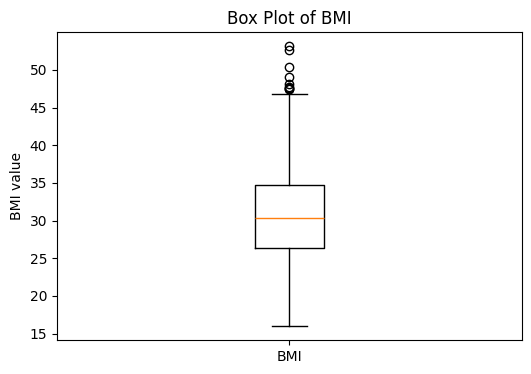

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['bmi'],tick_labels=['BMI'])
plt.title('Box Plot of BMI')
plt.ylabel('BMI value')
plt.show()

In [ ]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]
print(outliers)

      age  sex    bmi  children  smoker     region      charges
116    58    1  49.06         0       0  southeast  11381.32540
286    46    0  48.07         2       0  northeast   9432.92530
401    47    1  47.52         1       0  southeast   8083.91980
543    54    0  47.41         0       1  southeast  63770.42801
847    23    1  50.38         1       0  southeast   2438.05520
860    37    0  47.60         2       1  southwest  46113.51100
1047   22    1  52.58         1       1  southeast  44501.39820
1088   52    1  47.74         1       0  southeast   9748.91060
1317   18    1  53.13         0       0  southeast   1163.46270


In [ ]:
mean_bmi = df['bmi'].mean()
print(f"Mean BMI: {mean_bmi:.2f}")
df['bmi'] = df['bmi'].mask((df['bmi'] < lower) | (df['bmi'] > upper), mean_bmi)

Mean BMI: 30.66


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df.drop(columns=['charges', 'region', 'children'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [ ]:
predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


R2 Score: 0.84
Mean Absolute Error: 2703.46
Mean Squared Error: 24322876.49
Root Mean Squared Error: 4931.82


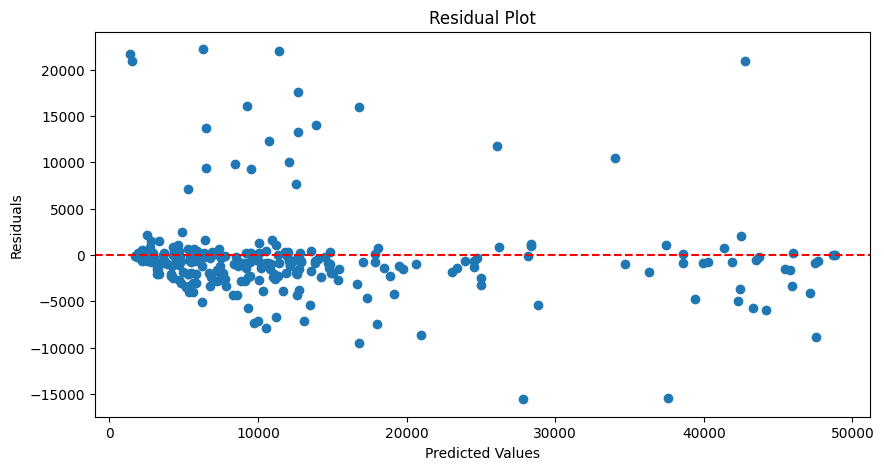

In [ ]:
residuals = y_test - predictions  # predictions from rf_model

plt.figure(figsize=(10,5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()